# Notebook 00a — Inspect yfinance Data

**Purpose:** Detailed inspection of the 4 price series from Yahoo Finance.

## Series Inspected

| Series | Ticker | Economic Role |
|---|---|---|
| **eurusd** | EURUSD=X | TARGET — the asset we predict |
| **dxy** | DX-Y.NYB | US Dollar Index (EUR is 57.6% of its weight) |
| **gold** | GC=F | Safe haven, inverse to USD |
| **oil** | CL=F | Commodity benchmark, risk appetite proxy |

## For Each Series

- Statistical summary (mean, std, min/max, missing)
- Time-series plot
- Distribution histogram
- Economic interpretation

**Output:** Charts saved to `figures/data_inspection/yfinance/`

---

**Author:** Dong Cong Gia Khang   
**Date:** May 2026

## 1. Setup

In [15]:
"""
Setup imports and paths.
"""
import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_project_root(marker=".env"):
    """Find project root by looking for a marker file."""
    current = Path.cwd()
    for parent in [current] + list(current.parents):
        if (parent / marker).exists():
            return parent
    raise RuntimeError(f"Could not find {marker}")


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))

# Paths
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "yfinance"
FIG_DIR = PROJECT_ROOT / "figures" / "data_inspection" / "yfinance"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Plot style
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["savefig.dpi"] = 120
plt.rcParams["savefig.bbox"] = "tight"

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data:     {RAW_DIR}")
print(f"Figures:      {FIG_DIR}")

Project root: d:\Final Project 2
Raw data:     d:\Final Project 2\data\raw\yfinance
Figures:      d:\Final Project 2\figures\data_inspection\yfinance


## 2. Inspection Helper Function

A reusable function to inspect any single price series: load, compute stats, plot line + distribution, and save charts.

In [16]:
"""
Helper function to inspect one price series.
"""
def inspect_price_series(name, description, category):
    """
    Inspect a single yfinance price series.

    Args:
        name: file name without extension (e.g., 'eurusd')
        description: economic meaning
        category: classification

    Returns:
        Dict of summary statistics
    """
    # ----- Load -----
    df = pd.read_csv(RAW_DIR / f"{name}.csv")
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)
    series = df["Close"]

    # ----- Print stats -----
    print(f"\n{'='*70}")
    print(f"  {name.upper()}  ({category})")
    print(f"{'='*70}")
    print(f"Description: {description}")
    print(f"Shape: {df.shape}")
    print(f"Date range: {df['Date'].min().date()} -> {df['Date'].max().date()}")
    print(f"Missing: {series.isnull().sum()} ({series.isnull().sum()/len(series)*100:.1f}%)")
    print(f"\nStatistics:")
    print(f"  mean:   {series.mean():12.4f}")
    print(f"  std:    {series.std():12.4f}")
    print(f"  min:    {series.min():12.4f}  on {df.loc[series.idxmin(), 'Date'].date()}")
    print(f"  max:    {series.max():12.4f}  on {df.loc[series.idxmax(), 'Date'].date()}")
    print(f"  latest: {series.iloc[-1]:12.4f}  on {df['Date'].iloc[-1].date()}")

    # ----- Plot: line + distribution -----
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))

    # Line plot
    ax1.plot(df["Date"], series, color="navy", linewidth=0.8)
    ax1.set_title(f"{name.upper()} — Time Series", fontsize=12, fontweight="bold")
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Close")
    ax1.grid(True, alpha=0.3)

    # Distribution
    ax2.hist(series.dropna(), bins=50, color="steelblue", alpha=0.7, edgecolor="white")
    ax2.axvline(series.mean(), color="red", linestyle="--", linewidth=1,
                label=f"mean={series.mean():.2f}")
    ax2.axvline(series.median(), color="green", linestyle="--", linewidth=1,
                label=f"median={series.median():.2f}")
    ax2.set_title(f"{name.upper()} — Distribution", fontsize=12, fontweight="bold")
    ax2.set_xlabel("Close")
    ax2.set_ylabel("Frequency")
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    out_path = FIG_DIR / f"{name}.png"
    plt.savefig(out_path)
    plt.show()
    print(f"\nSaved: {out_path.relative_to(PROJECT_ROOT)}")

    return {
        "name": name,
        "rows": len(df),
        "missing": int(series.isnull().sum()),
        "mean": round(series.mean(), 4),
        "std": round(series.std(), 4),
        "min": round(series.min(), 4),
        "max": round(series.max(), 4),
    }


print("Helper function defined")

Helper function defined


## 3. EUR/USD — Target Asset

The exchange rate we aim to predict. Range historically 0.96 - 1.48.


  EURUSD  (target)
Description: EUR/USD spot exchange rate. This is our TARGET asset to forecast.
Shape: (4260, 2)
Date range: 2010-01-01 -> 2026-05-14
Missing: 0 (0.0%)

Statistics:
  mean:         1.1861
  std:          0.1109
  min:          0.9596  on 2022-09-28
  max:          1.4844  on 2011-04-29
  latest:       1.1715  on 2026-05-14


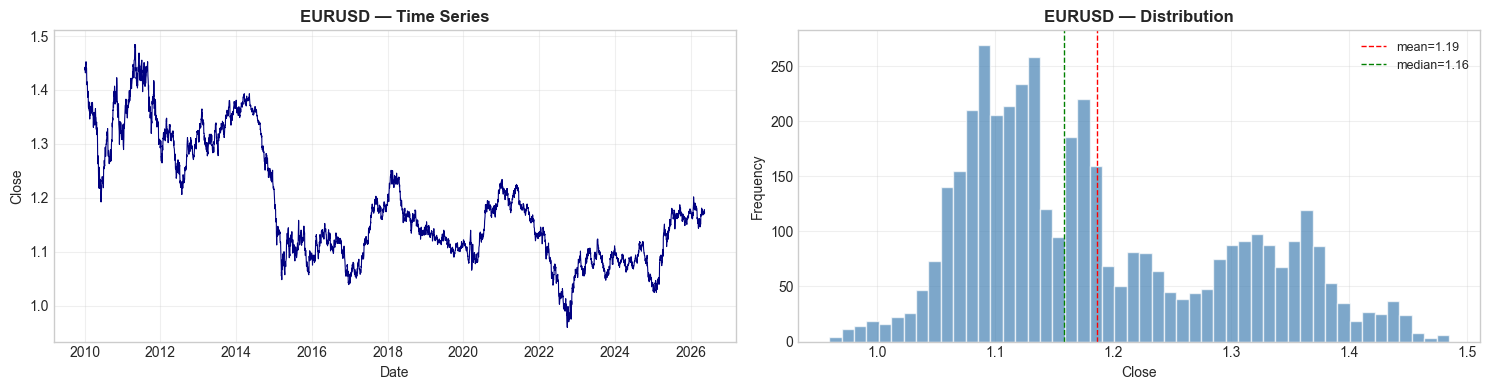


Saved: figures\data_inspection\yfinance\eurusd.png


In [17]:
summary_eurusd = inspect_price_series(
    name="eurusd",
    description="EUR/USD spot exchange rate. This is our TARGET asset to forecast.",
    category="target",
)

**Observations:**
- Range: ~0.96 (2022 parity crisis) to ~1.48 (2010 post-crisis)
- Long-term slight downward drift (EUR weakening vs USD over 16 years)
- Distribution roughly centered around 1.10-1.20

## 4. DXY — US Dollar Index

Measures USD strength vs a basket of 6 currencies (EUR is 57.6% weight). Should be **inversely** related to EUR/USD.


  DXY  (usd_strength)
Description: US Dollar Index. Inversely correlated with EUR/USD by construction (EUR is 57.6% of DXY).
Shape: (4117, 2)
Date range: 2010-01-04 -> 2026-05-14
Missing: 0 (0.0%)

Statistics:
  mean:        92.8629
  std:          9.3064
  min:         72.9300  on 2011-04-29
  max:        114.1100  on 2022-09-27
  latest:      98.4790  on 2026-05-14


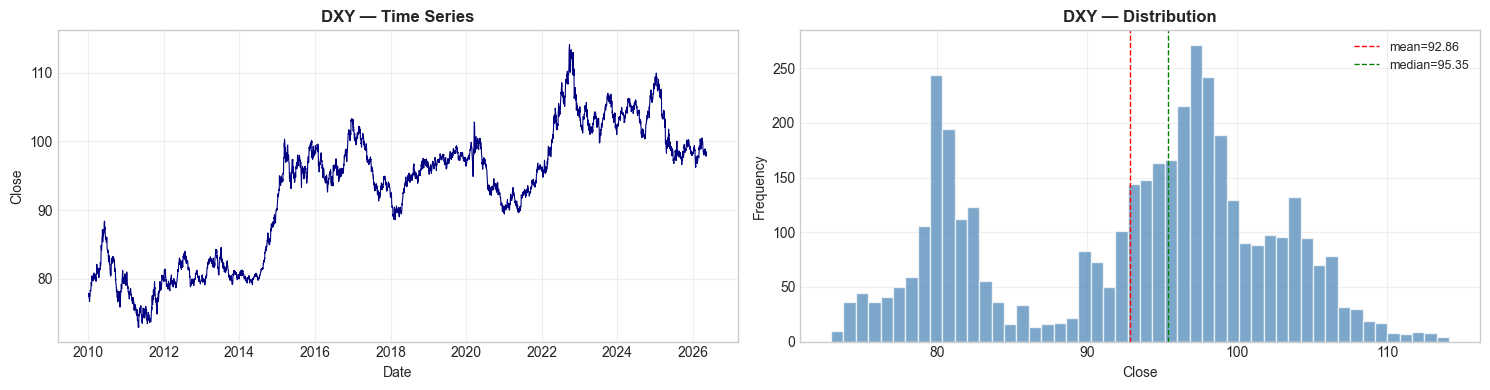


Saved: figures\data_inspection\yfinance\dxy.png


In [18]:
summary_dxy = inspect_price_series(
    name="dxy",
    description="US Dollar Index. Inversely correlated with EUR/USD by construction (EUR is 57.6% of DXY).",
    category="usd_strength",
)

**Observations:**
- Range: ~73 to ~114
- Inverse pattern vs EUR/USD (when DXY up, EUR/USD down)
- Strong uptrend 2021-2022 (Fed hiking cycle → strong USD)

## 5. Gold — Safe Haven

Gold futures. Tends to rise when USD weakens and during risk-off periods.


  GOLD  (safe_haven)
Description: Gold futures (GC=F). Safe haven asset, generally inverse to USD strength.
Shape: (4115, 2)
Date range: 2010-01-04 -> 2026-05-14
Missing: 0 (0.0%)

Statistics:
  mean:      1734.4506
  std:        743.4637
  min:       1050.8000  on 2015-12-17
  max:       5318.3999  on 2026-01-29
  latest:    4706.0000  on 2026-05-14


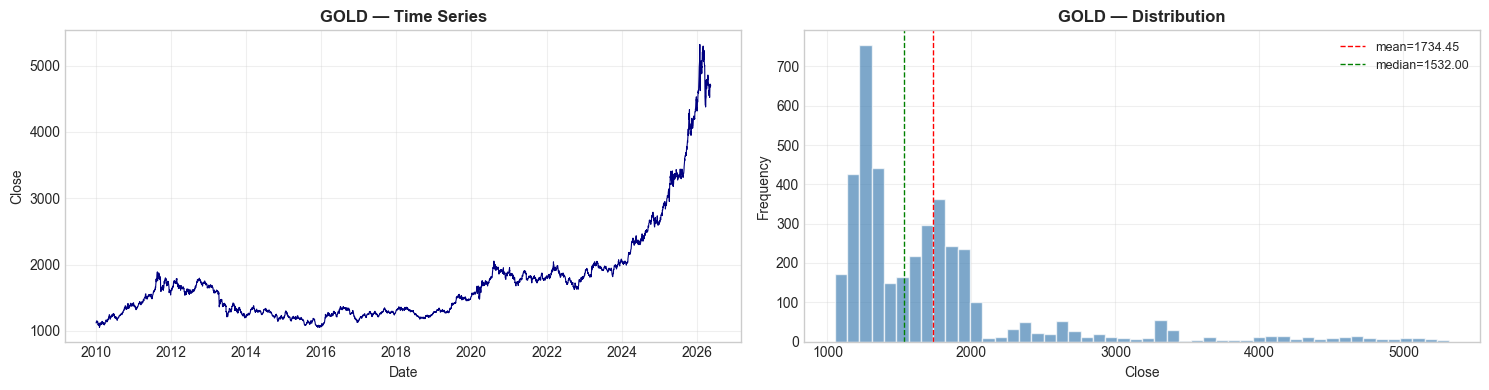


Saved: figures\data_inspection\yfinance\gold.png


In [19]:
summary_gold = inspect_price_series(
    name="gold",
    description="Gold futures (GC=F). Safe haven asset, generally inverse to USD strength.",
    category="safe_haven",
)

**Observations:**
- Strong long-term uptrend: ~1100 (2010) to ~4700 (2026)
- The upward trend reflects USD debasement + safe-haven demand
- Note: because of the trend, raw gold price is non-stationary (we'll use returns in modeling)

## 6. Oil — Commodity Benchmark

Crude Oil WTI futures. Reflects global growth expectations and risk appetite.


  OIL  (commodity)
Description: Crude Oil WTI futures (CL=F). Commodity benchmark, sensitive to global risk appetite.
Shape: (4116, 2)
Date range: 2010-01-04 -> 2026-05-14
Missing: 0 (0.0%)

Statistics:
  mean:        71.7642
  std:         20.7800
  min:        -37.6300  on 2020-04-20
  max:        123.7000  on 2022-03-08
  latest:     101.6100  on 2026-05-14


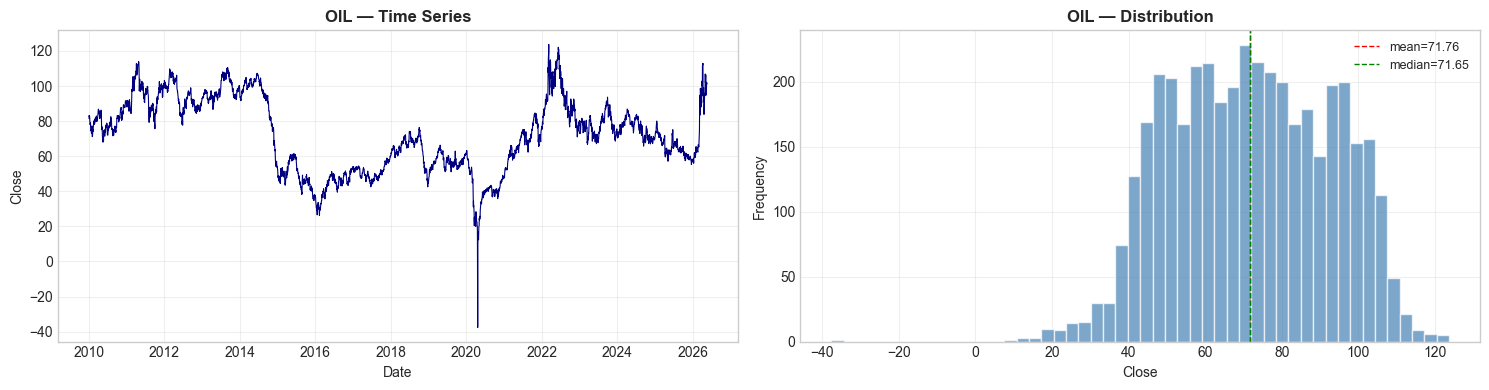


Saved: figures\data_inspection\yfinance\oil.png


In [20]:
summary_oil = inspect_price_series(
    name="oil",
    description="Crude Oil WTI futures (CL=F). Commodity benchmark, sensitive to global risk appetite.",
    category="commodity",
)

**Observations:**
- High volatility, range from **negative** (-37 in April 2020!) to ~120
- The negative price (April 2020) was a historic event: WTI futures expired during COVID storage crisis
- We keep this as a real market event, not an error

## 7. Summary — All yfinance Series

In [21]:
"""
Summary table of all 4 yfinance series.
"""
all_summaries = [summary_eurusd, summary_dxy, summary_gold, summary_oil]
summary_df = pd.DataFrame(all_summaries)

print("YFINANCE SERIES SUMMARY")
print("=" * 70)
print(summary_df.to_string(index=False))

# Verify charts saved
print(f"\nCharts saved in {FIG_DIR.relative_to(PROJECT_ROOT)}:")
for png in sorted(FIG_DIR.glob("*.png")):
    print(f"  - {png.name}")

YFINANCE SERIES SUMMARY
  name  rows  missing      mean      std       min       max
eurusd  4260        0    1.1861   0.1109    0.9596    1.4844
   dxy  4117        0   92.8629   9.3064   72.9300  114.1100
  gold  4115        0 1734.4506 743.4637 1050.8000 5318.3999
   oil  4116        0   71.7642  20.7800  -37.6300  123.7000

Charts saved in figures\data_inspection\yfinance:
  - dxy.png
  - eurusd.png
  - gold.png
  - oil.png


## Conclusion

### yfinance Data Summary

 Inspected all **4 price series**  
 All have ~4100-4260 rows, daily frequency, no missing values  
 Charts saved to `figures/data_inspection/yfinance/`

### Key Takeaways

| Series | Behavior | Modeling note |
|---|---|---|
| eurusd | Range-bound 0.96-1.48, slight downtrend | Target — use returns |
| dxy | Inverse to EUR/USD, mechanical | Strong predictor candidate |
| gold | Strong uptrend | Non-stationary — use returns |
| oil | High volatility, negative spike 2020 | Use returns, keep outliers |

### Next

`00b_inspect_fred.ipynb` — inspect the 13 macroeconomic series from FRED.